# Principal Component Analysis (PCA)

This notebook explores Principal Component Analysis (PCA), a dimensionality reduction technique that transforms data into a lower-dimensional space while preserving as much variance as possible. We'll apply PCA to the Wine dataset to understand how it can help visualize high-dimensional data and extract meaningful insights.

## Setup: Import Libraries

First, let's import all the necessary libraries for our analysis.

In [45]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

## 1. Apply PCA to the Wine Dataset

We'll use the Wine dataset, which contains 13 features related to chemical properties of wines from three different cultivars. Let's first load and explore this dataset.

In [46]:
# Load the Wine dataset
# ---------------------
# CODE HERE
datacsv = pd.read_csv("wine dataset.csv")
# ---------------------

# Display basic information about the dataset
# ---------------------
# CODE HERE
print(datacsv.info())
# ---------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    int64  
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    int64  
 13  class

### Data Preprocessing: Standardization

Before applying PCA, it's important to standardize the data. This ensures that all features contribute equally to the analysis, regardless of their original scale.

In [47]:
# Standardize the data (mean=0, variance=1)
# Use StandardScaler from scikit-learn to standardize the dataset
# Save the standardized features in X_wine_std
# ---------------------
# CODE HERE
X_wine = datacsv.drop("class", axis=1)
y_wine = datacsv["class"]
X_wine_std = StandardScaler().fit_transform(X_wine)
# ---------------------

# Verify standardization
print(f"Mean of each feature (should be close to 0): \n {X_wine_std.mean(axis=0)[:5]}...")
print()
print(f"Standard deviation of each feature (should be close to 1):\n {X_wine_std.std(axis=0)[:5]}...")

Mean of each feature (should be close to 0): 
 [-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17]...

Standard deviation of each feature (should be close to 1):
 [1. 1. 1. 1. 1.]...


### Apply PCA with 2 Components

Now, let's apply PCA to reduce our 13-dimensional data to 2 dimensions for visualization.

In [48]:
# Apply PCA with 2 components
# Use PCA from scikit-learn to perform PCA
# Save the transformed data in X_wine_pca
# ---------------------
# CODE HERE
wine = PCA(n_components=2)
X_wine_pca = wine.fit_transform(X_wine_std)
# ---------------------

# Examine the shape of transformed data
print(f"Shape after PCA transformation: {X_wine_pca.shape}")

# Display the variance explained by each component
print(f"Variance explained by each component: {wine.explained_variance_ratio_}")

# Display the total variance explained by the components
print(f"Total variance explained: {sum(wine.explained_variance_ratio_):.2%}")

Shape after PCA transformation: (178, 2)
Variance explained by each component: [0.36198848 0.1920749 ]
Total variance explained: 55.41%


### Visualize the 2D Projection

Let's create a scatter plot to visualize how our data looks after projection onto the first two principal components.

In [49]:
# Create a DataFrame for easier plotting
pca_df = pd.DataFrame(data=X_wine_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y_wine
pca_df['class'] = pca_df['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

# Display the first few rows of the dataframe
pca_df.head()

,PC1,PC2,target,class
0,3.316751,1.443463,0,class_0
1,2.209465,-0.333393,0,class_0
2,2.516740,1.031151,0,class_0
3,3.757066,2.756372,0,class_0
4,1.008908,0.869831,0,class_0


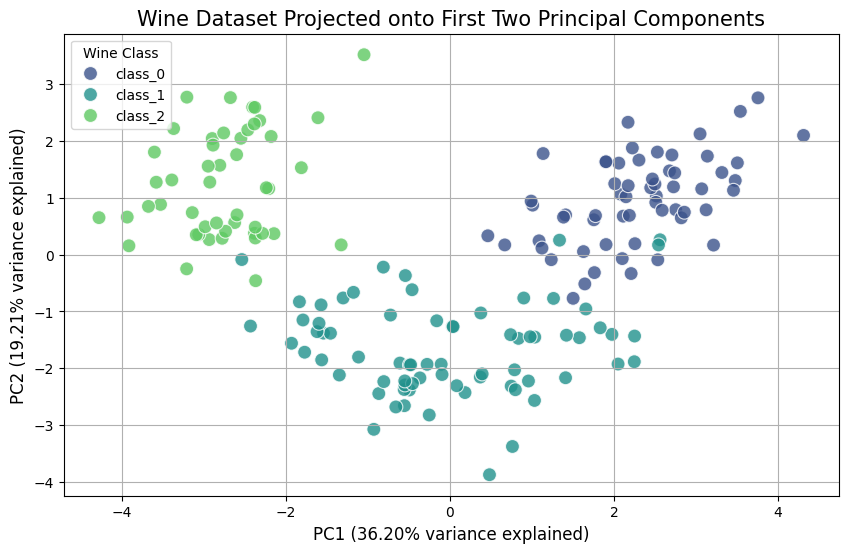

In [50]:
# Visualize the projected data colored by wine class
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='class', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('Wine Dataset Projected onto First Two Principal Components', fontsize=15)
plt.xlabel(f'PC1 ({wine.explained_variance_ratio_[0]:.2%} variance explained)', fontsize=12)
plt.ylabel(f'PC2 ({wine.explained_variance_ratio_[1]:.2%} variance explained)', fontsize=12)
plt.grid(True)
plt.legend(title='Wine Class')
plt.show()

### Analyze Feature Contributions

Now, let's examine how each original feature contributes to the principal components. This can help us understand which features are most important for distinguishing between classes.

The values in the heatmap represent the correlation between each feature and the principal components. 
- Positive values indicate a positive correlation.
- Negative values indicate a negative correlation.

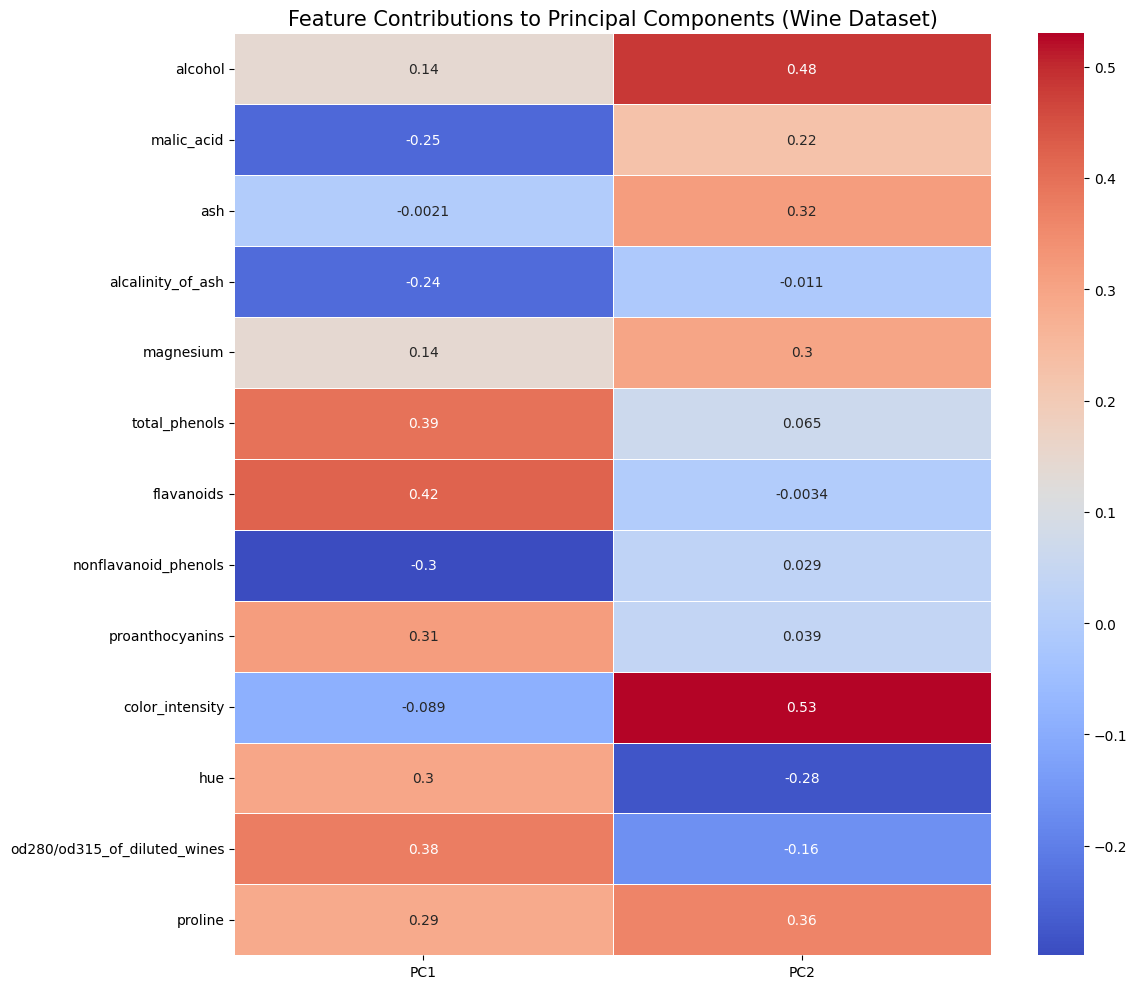

In [51]:
# Create a dataframe of component loadings
feature_names = X_wine.columns # wine.feature_names
components = pd.DataFrame(wine.components_.T, 
                        columns=['PC1', 'PC2'], 
                        index=feature_names)

# Visualize feature contributions using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(components, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Contributions to Principal Components (Wine Dataset)', fontsize=15)
plt.tight_layout()
plt.show()

## 2. Determining the Optimal Number of Components

A key question in PCA is how many components to retain. We can use the explained variance ratio to determine this. Let's apply PCA with all possible components and examine how much variance each component explains.

The threshold for explained variance is typically set at 80-90%. We can use a scree plot to visualize the explained variance ratio and determine the optimal number of components.

The optimal number of components is the point where the explained variance ratio starts to level off. This indicates that additional components contribute little to the overall variance.

In [52]:
# Apply PCA with all components
# Use PCA from scikit-learn to perform PCA without specifying the number of components
# Save the transformed data in X_wine_pca_full
# ---------------------
# CODE HERE
pca_full = PCA()
X_wine_pca_full = pca_full.fit_transform(X_wine_std)
# ---------------------

# Display explained variance for each component
explained_variance = pd.DataFrame({
    'Component': range(1, len(pca_full.explained_variance_ratio_) + 1),
    'Explained Variance': pca_full.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca_full.explained_variance_ratio_)
})
explained_variance.head(10)

,Component,Explained Variance,Cumulative Variance
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


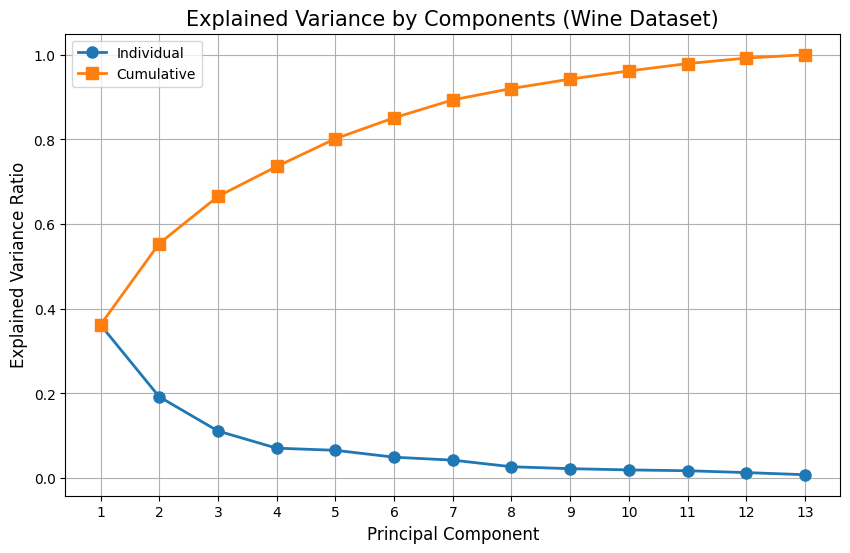

In [53]:
# Plot the explained variance ratio
plt.figure(figsize=(10, 6))

# Individual explained variance
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
        pca_full.explained_variance_ratio_, 'o-', linewidth=2, markersize=8)

# Cumulative explained variance
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
        np.cumsum(pca_full.explained_variance_ratio_), 's-', linewidth=2, markersize=8)

# Add labels and formatting
plt.title('Explained Variance by Components (Wine Dataset)', fontsize=15)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.grid(True)
plt.legend(['Individual', 'Cumulative'])
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.show()

It looks like the first 3 components explain over 70% of the variance in the data. 
Let's try visualizing the data in 3D using these 3 components.

## 3. 3D Visualization with PCA

Now, let's explore how our data looks when projected onto the first three principal components instead of just two.

In [54]:
# Apply PCA with 3 components
# Use PCA from scikit-learn to perform PCA with 3 components
# Save the transformed data in X_wine_pca_3d
# ---------------------
# CODE HERE
# 1. สร้าง PCA object โดยกำหนดให้เหลือ 3 components
pca_3d = PCA(n_components=3)
X_wine_pca_3d = pca_3d.fit_transform(X_wine_std)
# ---------------------

# Calculate total variance explained by these 3 components
total_variance_3d = sum(pca_3d.explained_variance_ratio_[:3])
print(f"Variance explained by first 3 components: {total_variance_3d:.2%}")
print(f"Variance by component: PC1={pca_3d.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca_full.explained_variance_ratio_[1]:.2%}, "
      f"PC3={pca_full.explained_variance_ratio_[2]:.2%}")

Variance explained by first 3 components: 66.53%
Variance by component: PC1=36.20%, PC2=19.21%, PC3=11.12%


In [55]:
# Create a DataFrame for 3D plotting
pca_3d_df = pd.DataFrame(data=X_wine_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_3d_df['target'] = y_wine
pca_3d_df['class'] = pca_3d_df['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

# Display the first few rows
pca_3d_df.head()

,PC1,PC2,PC3,target,class
0,3.316751,1.443463,-0.165739,0,class_0
1,2.209465,-0.333393,-2.026457,0,class_0
2,2.516740,1.031151,0.982819,0,class_0
3,3.757066,2.756372,-0.176192,0,class_0
4,1.008908,0.869831,2.026688,0,class_0


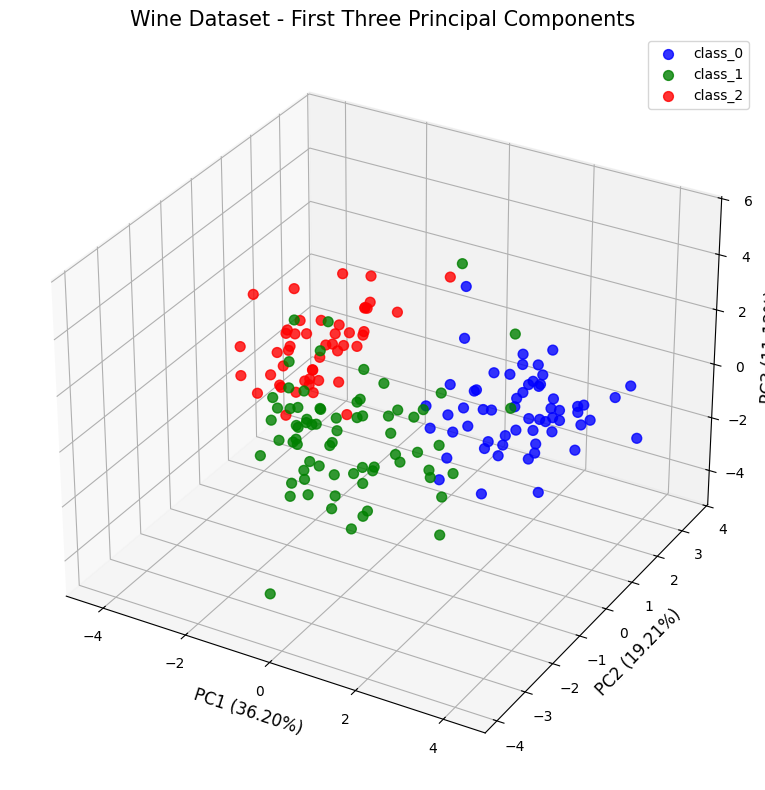

In [59]:
# Create 3D visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each class separately
for wine_class, color in zip(['class_0', 'class_1', 'class_2'], ['blue', 'green', 'red']):
    indices = pca_3d_df['class'] == wine_class
    ax.scatter(
        pca_3d_df.loc[indices, 'PC1'], 
        pca_3d_df.loc[indices, 'PC2'], 
        pca_3d_df.loc[indices, 'PC3'],
        c=color, 
        s=50, 
        alpha=0.8, 
        label=wine_class
    )

# Add labels and title
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})', fontsize=12)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})', fontsize=12)
ax.set_title('Wine Dataset - First Three Principal Components', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Conclusion and Key Insights

Let's summarize what we've learned from our PCA analysis of the Wine dataset:

1. **Dimensionality Reduction**: We reduced our 13-dimensional data to 2D and 3D representations while preserving most of the variance.
   
2. **Class Separation**: The PCA projections showed good separation between the three wine classes, indicating that the principal components captured the most important factors distinguishing between wine types.
   
3. **Feature Importance**: The heatmap showed which original features contributed most to each principal component, giving us insight into which chemical properties are most important for classification.
   
4. **Optimal Components**: The explained variance plot helped us understand how many components would be necessary to retain a desired percentage of the total variance in the data.

PCA is particularly valuable when working with high-dimensional data, as it allows us to visualize patterns and relationships that would otherwise be difficult to see.